In [ ]:
# ============================================
# Project Setup
# ============================================
# This project was originally developed in Google Colab.
# Instead of mounting Google Drive, place the dataset
# inside the project directory like this:

# project_folder/
# ├── data/
# │   └── traffic_light_split_dataset_npz.npz
# ├── models/
# └── notebook.ipynb

# Then load the dataset using the local path.

data_path = "data/traffic_light_split_dataset_npz.npz"

Mounted at /content/drive


In [ ]:
# ============================================
# Image Cropping (RUN ONCE)
# ============================================
# This step crops traffic sign regions from the original images
# using bounding box coordinates and saves them into class folders.
# It only needs to be executed once during dataset preparation.

import os
from PIL import Image
import shutil
import matplotlib.pyplot as plt

# Project paths
base_path = "data"
images_dir = os.path.join(base_path, "images")
cropped_dir = os.path.join(base_path, "cropped")

# Create cropped directory cleanly
if os.path.exists(cropped_dir):
    shutil.rmtree(cropped_dir)

os.makedirs(cropped_dir, exist_ok=True)

# Iterate over bounding boxes and crop images
for image_id, bboxes in bboxes_dict.items():

    found = False

    # Search image in dataset splits
    for split in ["train", "val", "test"]:

        image_path = os.path.join(images_dir, split, image_id + ".png")

        if os.path.exists(image_path):
            found = True
            break

        image_path_jpg = os.path.join(images_dir, split, image_id + ".jpg")

        if os.path.exists(image_path_jpg):
            image_path = image_path_jpg
            found = True
            break

    if not found:
        print(f"Skipping {image_id}: image not found")
        continue

    img = Image.open(image_path)

    # Crop each bounding box
    for idx, (class_id, x_min, y_min, x_max, y_max) in enumerate(bboxes):

        cropped_img = img.crop((x_min, y_min, x_max, y_max))

        class_dir = os.path.join(cropped_dir, f"class_{class_id}")
        os.makedirs(class_dir, exist_ok=True)

        cropped_img_path = os.path.join(class_dir, f"{image_id}_{idx}.png")
        cropped_img.save(cropped_img_path)

print(f"Cropping complete. Saved to: {cropped_dir}")

# ============================================
# Show sample cropped images
# ============================================

sample_class = os.listdir(cropped_dir)[0]
sample_imgs = os.listdir(os.path.join(cropped_dir, sample_class))[:5]

fig, axs = plt.subplots(1, len(sample_imgs), figsize=(15, 5))

for i, img_name in enumerate(sample_imgs):
    img_path = os.path.join(cropped_dir, sample_class, img_name)
    img = Image.open(img_path)

    axs[i].imshow(img)
    axs[i].axis('off')
    axs[i].set_title(sample_class)

plt.show()

In [ ]:
# ============================================
# Data Augmentation (RUN ONCE)
# ============================================
# This step generates augmented versions of the cropped images
# to increase dataset diversity. It was executed once during
# dataset preparation and the generated images were saved.

import os
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tqdm import tqdm

# Paths
cropped_dir = "data/cropped"
augmented_dir = "data/augmented"

# Ensure output directory exists
os.makedirs(augmented_dir, exist_ok=True)

# Data augmentation settings
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Loop through each class folder
classes = [c for c in os.listdir(cropped_dir) if os.path.isdir(os.path.join(cropped_dir, c))]
print(f"Found classes: {classes}")

for class_name in tqdm(classes, desc="Processing Classes"):

    class_input_dir = os.path.join(cropped_dir, class_name)
    class_output_dir = os.path.join(augmented_dir, class_name)

    os.makedirs(class_output_dir, exist_ok=True)

    images = os.listdir(class_input_dir)

    for img_name in images:

        img_path = os.path.join(class_input_dir, img_name)
        img = Image.open(img_path)

        img_array = np.expand_dims(np.array(img), axis=0)

        # Generate 5 augmented images
        aug_iter = datagen.flow(img_array, batch_size=1)

        for i in range(5):
            aug_img = next(aug_iter)[0].astype('uint8')

            save_path = os.path.join(
                class_output_dir,
                f"{os.path.splitext(img_name)[0]}_aug_{i+1}.png"
            )

            Image.fromarray(aug_img).save(save_path)

print(f"Augmented images saved to: {augmented_dir}")

'\nimport os\nimport numpy as np\nfrom PIL import Image\nfrom tensorflow.keras.preprocessing.image import ImageDataGenerator\nfrom tqdm import tqdm  # Progress bar\n\n# Base path to cropped images\ncropped_dir = \'/content/drive/MyDrive/DA450_project/Final_Dataset_Cropped/cropped\'\naugmented_dir = \'/content/drive/MyDrive/DA450_project/Final_Dataset_Cropped_Augmented\'\n\n# Ensure augmented directory is clean\nif not os.path.exists(augmented_dir):\n    os.makedirs(augmented_dir, exist_ok=True)\n\n# Data augmentation settings (same as before)\ndatagen = ImageDataGenerator(\n    rotation_range=20,\n    width_shift_range=0.1,\n    height_shift_range=0.1,\n    zoom_range=0.2,\n    brightness_range=(0.8, 1.2),\n    horizontal_flip=True,\n    fill_mode=\'nearest\'\n)\n\n# Loop through each class folder\nclasses = [c for c in os.listdir(cropped_dir) if os.path.isdir(os.path.join(cropped_dir, c))]\nprint(f"Found classes: {classes}")\n\nfor class_name in tqdm(classes, desc="Processing Classes"

In [ ]:
# ============================================
# Build Dataset from Augmented Images (RUN ONCE)
# ============================================
# This step loads augmented images, resizes them to 64x64,
# and builds a dataset list of (image_array, class_id).
# It was executed once during dataset preparation.

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

# Path to augmented images
augmented_dir = "data/augmented"

# Store (image, class_id)
dataset = []

# Loop over class folders
for class_name in os.listdir(augmented_dir):

    if not class_name.startswith("class_"):
        continue

    class_dir = os.path.join(augmented_dir, class_name)

    if not os.path.isdir(class_dir):
        continue

    class_id = int(class_name.split("_")[-1])

    for img_file in os.listdir(class_dir):

        img_path = os.path.join(class_dir, img_file)

        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize((64, 64))  # resize for CNN
            img_array = np.array(img)

            dataset.append((img_array, class_id))

        except Exception as e:
            print(f"Error loading {img_path}: {e}")

print(f"Total images loaded: {len(dataset)}")

# Show random sample
sample_img, sample_label = random.choice(dataset)

plt.imshow(sample_img)
plt.axis("off")
plt.title(f"Class ID: {sample_label}")
plt.show()

'\nimport os\nimport numpy as np\nfrom PIL import Image\n\n# Path to augmented images directory\naugmented_dir = \'/content/drive/MyDrive/DA450_project/Final_Dataset_Cropped_Augmented\'\n\n# Initialize list to store (image, class_id)\ndataset = []\n\n# Loop over class folders\nfor class_name in os.listdir(augmented_dir):\n    if not class_name.startswith(\'class_\'):\n        continue  # skip folders like \'labels\', \'images\', etc.\n\n    class_dir = os.path.join(augmented_dir, class_name)\n    if not os.path.isdir(class_dir):\n        continue  # just to be safe\n\n    class_id = int(class_name.split(\'_\')[-1])  # now safe, only for class_0, class_1, etc.\n\n    # Loop over images in this class folder\n    for img_file in os.listdir(class_dir):\n        img_path = os.path.join(class_dir, img_file)\n        try:\n            img = Image.open(img_path).convert(\'RGB\')\n            img = img.resize((64, 64))  # resize for CNN model\n            img_array = np.array(img)\n            

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import numpy as np

data = np.load('/content/drive/MyDrive/DA450_project/traffic_light_split_dataset_npz.npz')

X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']





total_images = len(y_train) + len(y_val) + len(y_test)
print(f" Total images in dataset: {total_images}")
print(f" Train set: {len(y_train)} images")
print(f" Validation set: {len(y_val)} images")
print(f" Test set: {len(y_test)} images")






def count_classes(labels):
    unique, counts = np.unique(labels, return_counts=True)
    return dict(zip(unique, counts))





print("\n Class distribution per split:")

for name, labels in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    class_counts = count_classes(labels)
    print(f"\n{name} Set:")
    for cls in sorted(class_counts):
        print(f"  Class {cls}: {class_counts[cls]} images")


 Total images in dataset: 52830
 Train set: 36980 images
 Validation set: 7924 images
 Test set: 7926 images

 Class distribution per split:

Train Set:
  Class 0: 5250 images
  Class 1: 5470 images
  Class 2: 5260 images
  Class 3: 5250 images
  Class 4: 5250 images
  Class 5: 5250 images
  Class 6: 5250 images

Validation Set:
  Class 0: 1125 images
  Class 1: 1172 images
  Class 2: 1127 images
  Class 3: 1125 images
  Class 4: 1125 images
  Class 5: 1125 images
  Class 6: 1125 images

Test Set:
  Class 0: 1125 images
  Class 1: 1173 images
  Class 2: 1128 images
  Class 3: 1125 images
  Class 4: 1125 images
  Class 5: 1125 images
  Class 6: 1125 images


Exception ignored in: <function NpzFile.__del__ at 0x7b1c4c562660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
  File "/usr/local/lib/python3.11/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
OSError: [Errno 107] Transport endpoint is not connected


Total images: 52830


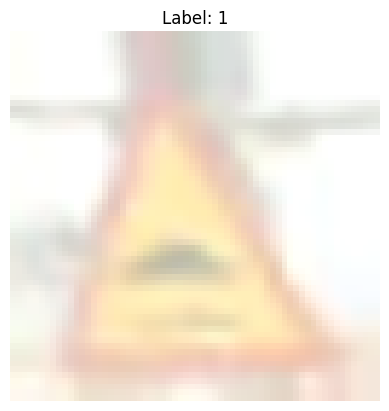

In [ ]:
# ============================================
# Display any image from the dataset
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Load dataset from local project folder
data_path = "data/traffic_light_split_dataset_npz.npz"
data = np.load(data_path)

# Concatenate all splits for easy indexing
X_all = np.concatenate((data['X_train'], data['X_val'], data['X_test']))
y_all = np.concatenate((data['y_train'], data['y_val'], data['y_test']))

print(f"Total images: {len(X_all)}")

def show_image(index):
    if index >= len(X_all):
        print(f"Index {index} is out of range! Max is {len(X_all)-1}")
        return

    plt.imshow(X_all[index])
    plt.title(f"Label: {y_all[index]}")
    plt.axis('off')
    plt.show()

# Example: show image at index 10000
show_image(10000)  # Change this number between 0 and len(X_all)-1

Epoch 1/5
2312/2312 ━━━━━━━━━━━━━━━━━━━━ 300s 129ms/step - accuracy: 0.9028 - loss: 0.3003 - val_accuracy: 0.9893 - val_loss: 0.0428
Epoch 2/5
2312/2312 ━━━━━━━━━━━━━━━━━━━━ 312s 124ms/step - accuracy: 0.9852 - loss: 0.0557 - val_accuracy: 0.9865 - val_loss: 0.0566
Epoch 3/5
2312/2312 ━━━━━━━━━━━━━━━━━━━━ 329s 128ms/step - accuracy: 0.9885 - loss: 0.0451 - val_accuracy: 0.9922 - val_loss: 0.0432
Epoch 4/5
2312/2312 ━━━━━━━━━━━━━━━━━━━━ 294s 127ms/step - accuracy: 0.9933 - loss: 0.0293 - val_accuracy: 0.9956 - val_loss: 0.0247
Epoch 5/5
2312/2312 ━━━━━━━━━━━━━━━━━━━━ 321s 126ms/step - accuracy: 0.9933 - loss: 0.0267 - val_accuracy: 0.9950 - val_loss: 0.0227
248/248 - 14s - 57ms/step - accuracy: 0.9944 - loss: 0.0296
Test Accuracy: 0.9944
Test Loss: 0.0296


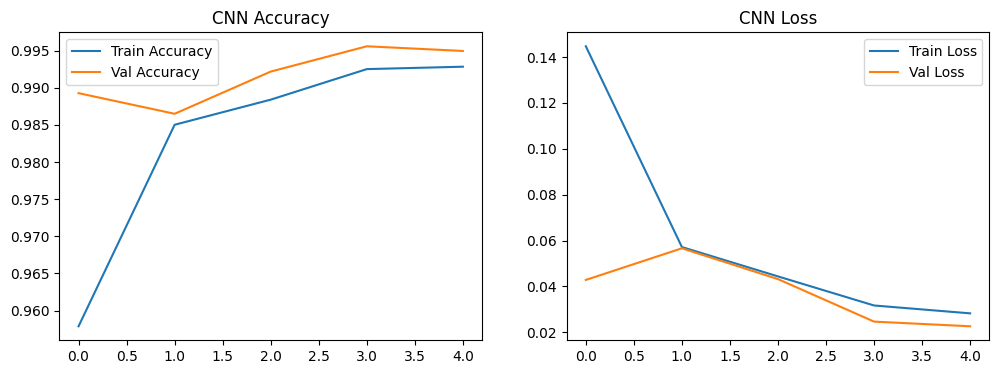

In [ ]:
# ============================================
# Train CNN on traffic light dataset
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Load dataset from local folder
data_path = "data/traffic_light_split_dataset_npz.npz"
data = np.load(data_path)
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']

# Normalize images
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# One-hot encode labels
num_classes = len(np.unique(y_train))
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

# Build CNN model
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
cnn_history = cnn_model.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=16,
    validation_data=(X_val, y_val_cat)
)

# Evaluate on test set
test_loss, test_acc = cnn_model.evaluate(X_test, y_test_cat, verbose=2)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Val Accuracy')
plt.title("CNN Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='Train Loss')
plt.plot(cnn_history.history['val_loss'], label='Val Loss')
plt.title("CNN Loss")
plt.legend()
plt.show()

# Save the trained model locally
cnn_model.save("models/cnn_model.h5")

In [ ]:
# ============================================
# Evaluate CNN model on test set
# ============================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model

# Load the trained CNN model (local path)
cnn_model_path = "models/cnn_model.h5"
model = load_model(cnn_model_path)

# Load test dataset (local path)
data_path = "data/traffic_light_split_dataset_npz.npz"
data = np.load(data_path)
X_test = data['X_test'] / 255.0
y_test = data['y_test']

# Predict on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print classification metrics
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# Print confusion matrix
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

248/248 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step
=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1125
           1       1.00      0.98      0.99      1173
           2       0.99      1.00      0.99      1128
           3       0.99      1.00      0.99      1125
           4       1.00      1.00      1.00      1125
           5       0.99      1.00      0.99      1125
           6       1.00      1.00      1.00      1125

    accuracy                           0.99      7926
   macro avg       0.99      0.99      0.99      7926
weighted avg       0.99      0.99      0.99      7926

=== Confusion Matrix ===
[[1116    2    3    0    2    2    0]
 [   0 1155    4    8    1    5    0]
 [   1    0 1124    1    0    2    0]
 [   0    1    0 1123    0    0    1]
 [   0    0    0    0 1123    2    0]
 [   0    0    1    1    1 1121    1]
 [   0    1    0    2    0    2 1120]]


<ipython-input-11-cc8c6e9b2072>:25: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=X_train.shape[1:], include_top=False, weights='imagenet')


Epoch 1/5
2312/2312 ━━━━━━━━━━━━━━━━━━━━ 160s 67ms/step - accuracy: 0.9433 - loss: 0.1948 - val_accuracy: 0.9792 - val_loss: 0.0689
Epoch 2/5
2312/2312 ━━━━━━━━━━━━━━━━━━━━ 200s 66ms/step - accuracy: 0.9878 - loss: 0.0397 - val_accuracy: 0.9830 - val_loss: 0.0584
Epoch 3/5
2312/2312 ━━━━━━━━━━━━━━━━━━━━ 133s 58ms/step - accuracy: 0.9931 - loss: 0.0257 - val_accuracy: 0.9814 - val_loss: 0.0628
Epoch 4/5
2312/2312 ━━━━━━━━━━━━━━━━━━━━ 137s 59ms/step - accuracy: 0.9936 - loss: 0.0242 - val_accuracy: 0.9799 - val_loss: 0.0759
Epoch 5/5
2312/2312 ━━━━━━━━━━━━━━━━━━━━ 152s 66ms/step - accuracy: 0.9940 - loss: 0.0185 - val_accuracy: 0.9838 - val_loss: 0.0663


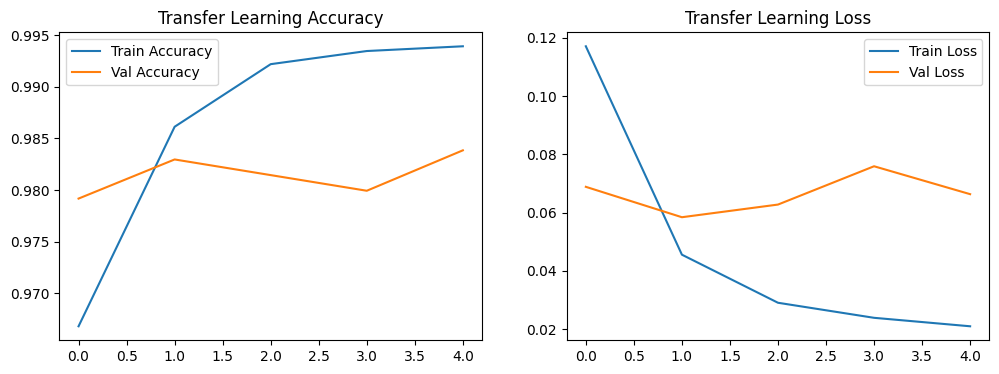

In [ ]:
# ============================================
# Transfer Learning with MobileNetV2
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Load dataset from local folder
data_path = "data/traffic_light_split_dataset_npz.npz"
data = np.load(data_path)
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']

# Normalize images
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# One-hot encode labels
num_classes = len(np.unique(y_train))
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

# Transfer Learning: MobileNetV2
base_model = MobileNetV2(input_shape=X_train.shape[1:], include_top=False, weights='imagenet')
base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the transfer learning model
transfer_history = transfer_model.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=16,
    validation_data=(X_val, y_val_cat)
)

# Plot training results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(transfer_history.history['accuracy'], label='Train Accuracy')
plt.plot(transfer_history.history['val_accuracy'], label='Val Accuracy')
plt.title("Transfer Learning Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(transfer_history.history['loss'], label='Train Loss')
plt.plot(transfer_history.history['val_loss'], label='Val Loss')
plt.title("Transfer Learning Loss")
plt.legend()
plt.show()

# Save the trained transfer model locally
transfer_model.save("models/transfer_model.h5")

In [ ]:
# ============================================
# Evaluate Transfer Learning Model on Test Set
# ============================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model

# Load the trained transfer model (local path)
transfer_model_path = "models/transfer_model.h5"
model = load_model(transfer_model_path)

# Load test dataset (local path)
data_path = "data/traffic_light_split_dataset_npz.npz"
data = np.load(data_path)
X_test = data['X_test'] / 255.0
y_test = data['y_test']

# Predict on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print classification metrics
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# Print confusion matrix
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

248/248 ━━━━━━━━━━━━━━━━━━━━ 24s 88ms/step
=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1125
           1       0.99      0.97      0.98      1173
           2       0.99      0.99      0.99      1128
           3       0.98      0.99      0.99      1125
           4       0.97      0.99      0.98      1125
           5       0.98      0.98      0.98      1125
           6       0.99      0.97      0.98      1125

    accuracy                           0.98      7926
   macro avg       0.98      0.98      0.98      7926
weighted avg       0.98      0.98      0.98      7926

=== Confusion Matrix ===
[[1113    1    1    1    8    1    0]
 [   6 1139    2   11    2   11    2]
 [   6    2 1118    0    2    0    0]
 [   1    6    1 1113    1    2    1]
 [   4    1    1    1 1115    0    3]
 [   5    6    0    2    3 1108    1]
 [   4    0    2    3   16    5 1095]]


248/248 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step
248/248 ━━━━━━━━━━━━━━━━━━━━ 27s 104ms/step


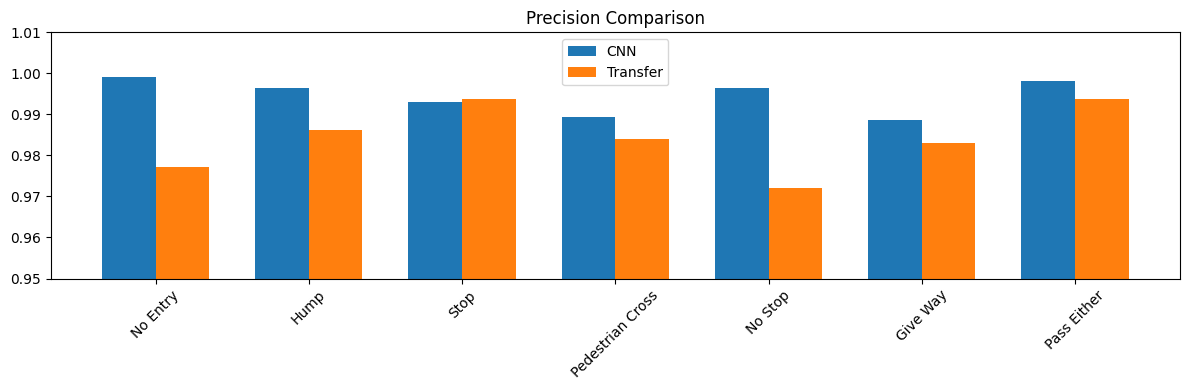

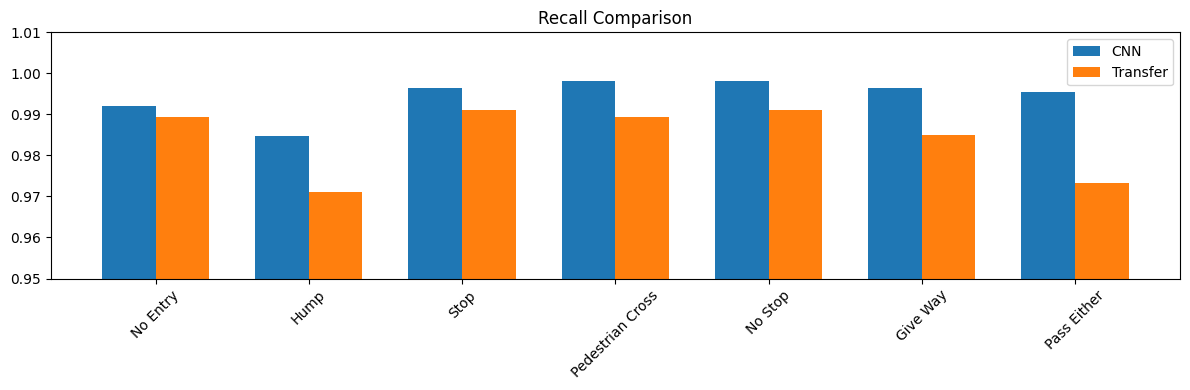

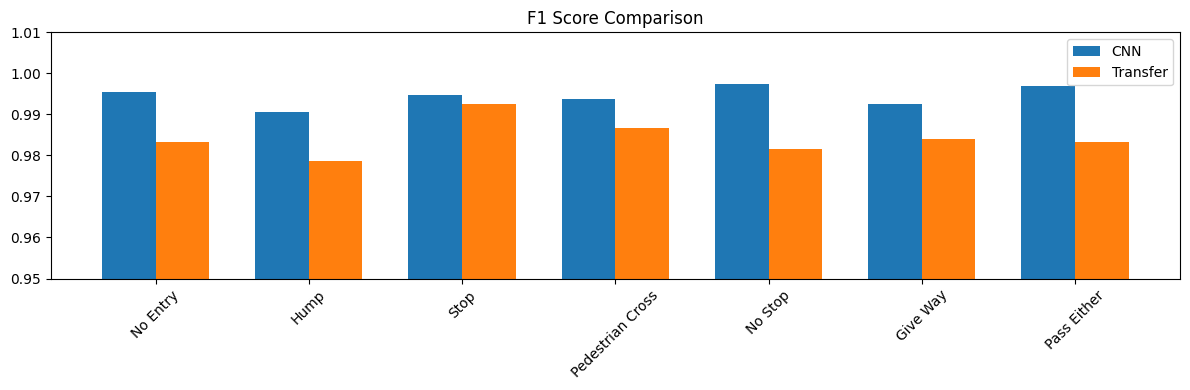

In [ ]:
# ============================================
# Compare CNN vs Transfer Learning Metrics
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow.keras.models import load_model

# Load test dataset (local path)
data_path = "data/traffic_light_split_dataset_npz.npz"
data = np.load(data_path)
X_test = data['X_test'] / 255.0
y_test = data['y_test']

# Load models (local paths)
cnn_model = load_model("models/cnn_model.h5")
transfer_model = load_model("models/transfer_model.h5")

# Predict on test set
cnn_preds = np.argmax(cnn_model.predict(X_test), axis=1)
trans_preds = np.argmax(transfer_model.predict(X_test), axis=1)

# Compute metrics per class
cnn_precision = precision_score(y_test, cnn_preds, average=None)
cnn_recall = recall_score(y_test, cnn_preds, average=None)
cnn_f1 = f1_score(y_test, cnn_preds, average=None)

trans_precision = precision_score(y_test, trans_preds, average=None)
trans_recall = recall_score(y_test, trans_preds, average=None)
trans_f1 = f1_score(y_test, trans_preds, average=None)

# Class names
classes = ["No Entry", "Hump", "Stop", "Pedestrian Cross", "No Stop", "Give Way", "Pass Either"]
x = np.arange(len(classes))
width = 0.35

# Plot Precision
plt.figure(figsize=(12, 4))
plt.bar(x - width/2, cnn_precision, width, label='CNN')
plt.bar(x + width/2, trans_precision, width, label='Transfer')
plt.xticks(x, classes, rotation=45)
plt.ylim(0, 1.0)
plt.title("Precision Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Plot Recall
plt.figure(figsize=(12, 4))
plt.bar(x - width/2, cnn_recall, width, label='CNN')
plt.bar(x + width/2, trans_recall, width, label='Transfer')
plt.xticks(x, classes, rotation=45)
plt.ylim(0, 1.0)
plt.title("Recall Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Plot F1 Score
plt.figure(figsize=(12, 4))
plt.bar(x - width/2, cnn_f1, width, label='CNN')
plt.bar(x + width/2, trans_f1, width, label='Transfer')
plt.xticks(x, classes, rotation=45)
plt.ylim(0, 1.0)
plt.title("F1 Score Comparison")
plt.legend()
plt.tight_layout()
plt.show()

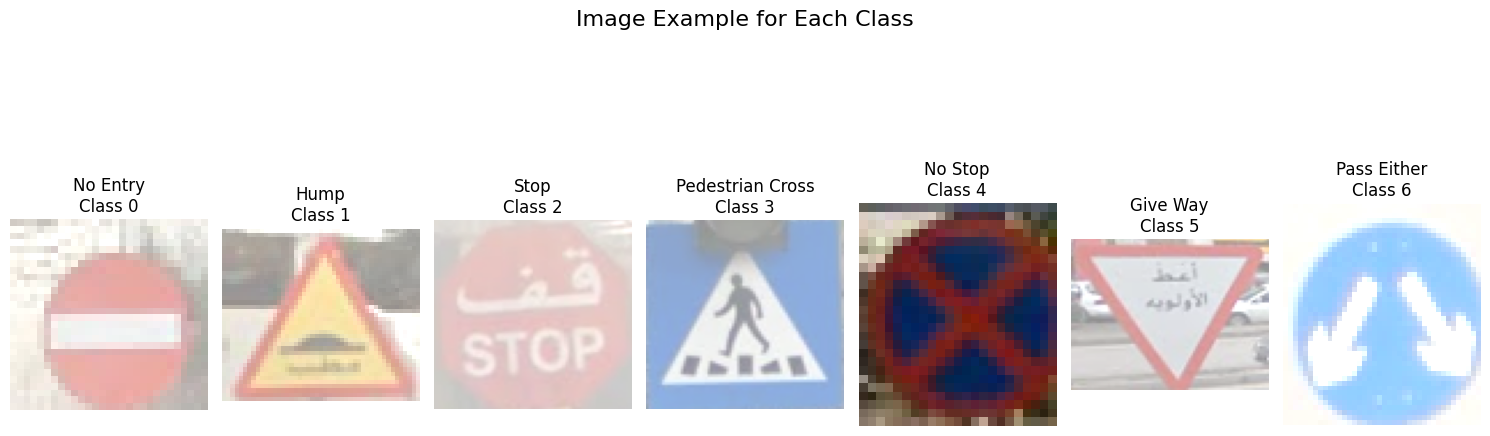

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


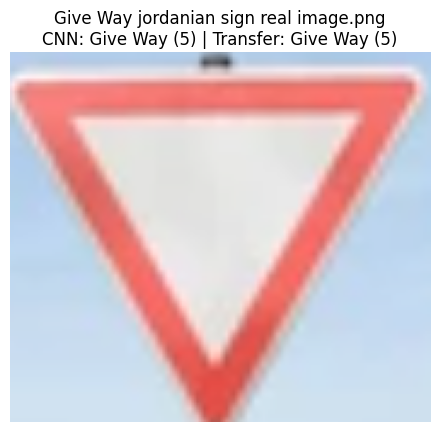

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


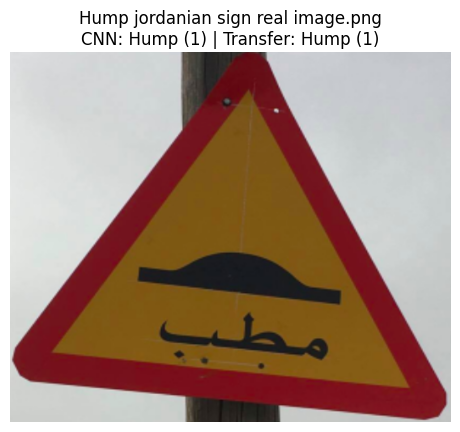

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


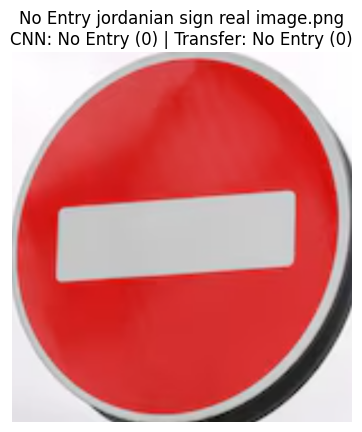

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


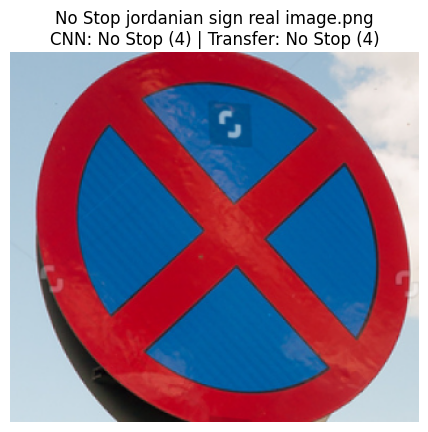

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


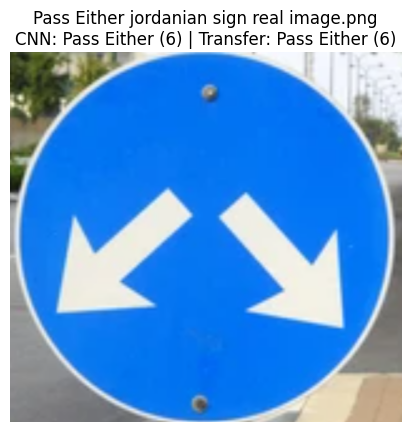

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


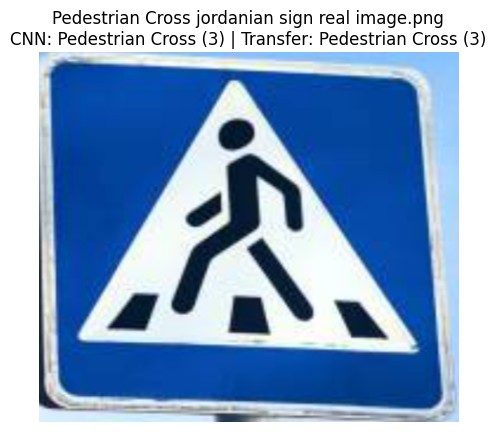

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


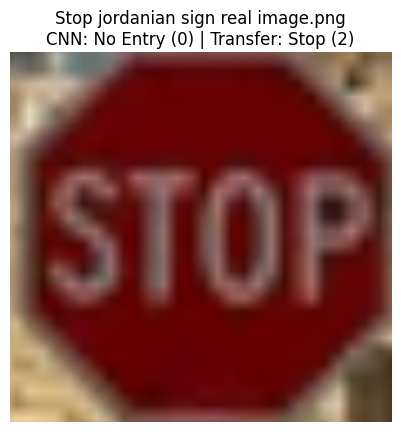

In [ ]:
# ============================================
# Show Example Images with Predictions
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model

# Paths
example_dir = "examples_per_class"  # ضع الصور هنا في مجلد داخل المشروع
cnn_model_path = "models/cnn_model.h5"
transfer_model_path = "models/transfer_model.h5"

# Class names (match dataset)
class_names = [
    "No Entry",          # 0
    "Hump",              # 1
    "Stop",              # 2
    "Pedestrian Cross",  # 3
    "No Stop",           # 4
    "Give Way",          # 5
    "Pass Either"        # 6
]

# Load models
cnn_model = load_model(cnn_model_path)
transfer_model = load_model(transfer_model_path)

# Get image files in the example directory
image_files = sorted(os.listdir(example_dir))  # Keep order consistent

# Loop through each image
for file in image_files:
    img_path = os.path.join(example_dir, file)
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize((64, 64))  # Resize for CNN input

    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    cnn_pred = np.argmax(cnn_model.predict(img_array), axis=1)[0]
    transfer_pred = np.argmax(transfer_model.predict(img_array), axis=1)[0]

    # Display image with predictions
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{file}\nCNN: {class_names[cnn_pred]} ({cnn_pred}) | Transfer: {class_names[transfer_pred]} ({transfer_pred})")
    plt.show()